# PCA Analysis for Tournament Model Advanced Data

This notebook performs PCA on `data/tournament_model_adv_ml.csv`, visualizes explained variance and principal components, and saves PCA-transformed train/test datasets as CSV files.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
# Load the dataset
df = pd.read_csv('data/tournament_model_adv_ml.csv')

features = ['SRS_diff', 'win_pct_diff', 'eFG%_diff', 'TS%_diff', 'TRB%_diff', 'AST%_diff', 'TOV%_diff', 'ORtg_diff']

train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['SRS_diff', 'win_pct_diff', 'eFG%_diff', 'TS%_diff', 'TRB%_diff', 'AST%_diff', 'TOV%_diff', 'ORtg_diff']


In [14]:
# Build a pipeline with scaling and PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pca_pipeline.fit(X_train)
pca = pca_pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.5175
  PC2: 0.1493
  PC3: 0.1430
  PC4: 0.0939
  PC5: 0.0509
  PC6: 0.0375
  PC7: 0.0055
  PC8: 0.0024

Cumulative explained variance:
  PC1: 0.5175
  PC2: 0.6668
  PC3: 0.8098
  PC4: 0.9037
  PC5: 0.9546
  PC6: 0.9921
  PC7: 0.9976
  PC8: 1.0000


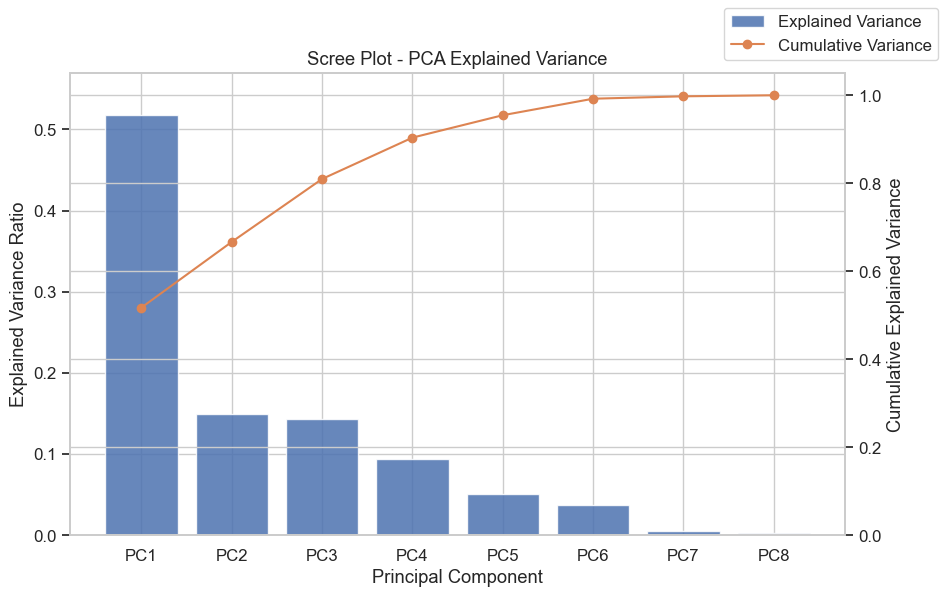

In [15]:
# Visualize the explained variance
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [16]:
# Build a DataFrame with PCA scores for the training data
n_components = 5

pca_model = PCA(n_components=n_components)
X_train_scaled = pca_pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)

# Attach the target and season for inspection only
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3,PC4,PC5
0,2015,1,2.203333,-1.572927,1.260497,0.414216,0.564670
1,2015,1,1.760041,-1.151907,-0.686302,-2.015065,0.268278
2,2015,1,-0.114038,-2.261353,0.216276,-0.342863,0.471754
3,2015,1,0.751553,1.353481,-0.980759,0.073736,0.226067
4,2015,1,0.113386,-0.856665,-0.277984,0.920446,1.314973


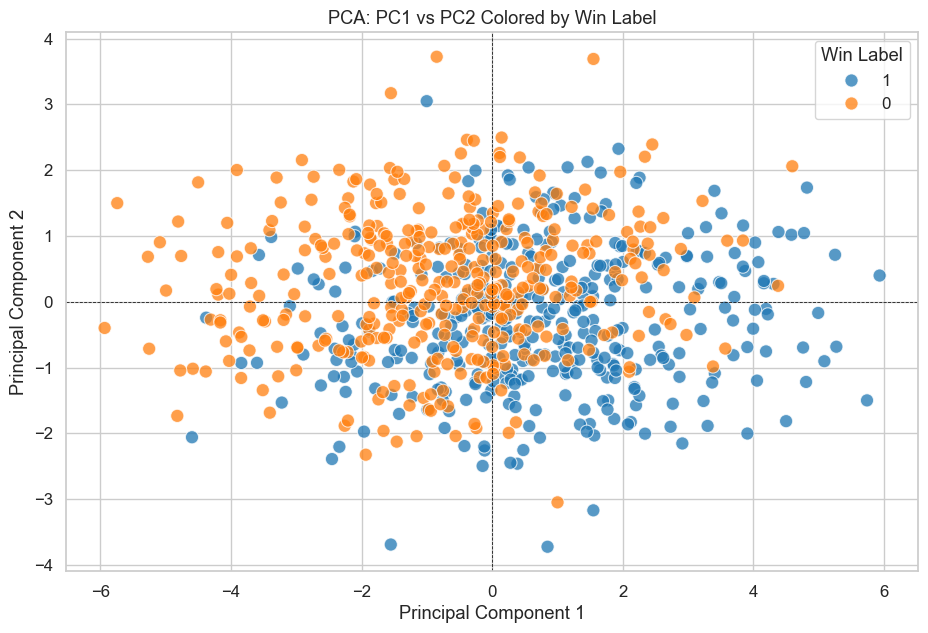

In [17]:
# Scatter plot of the first two principal components
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

In [18]:
# Compare feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5
SRS_diff,0.341,-0.384,0.207,0.191,0.806
win_pct_diff,0.402,-0.221,0.141,-0.147,-0.302
eFG%_diff,0.416,0.389,-0.225,-0.188,0.063
TS%_diff,0.418,0.374,-0.229,-0.202,0.107
TRB%_diff,0.240,-0.161,0.705,-0.295,-0.295
AST%_diff,0.202,0.423,0.325,0.804,-0.159
TOV%_diff,-0.231,0.553,0.461,-0.361,0.352
ORtg_diff,0.471,-0.037,-0.140,-0.038,-0.085


In [19]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pca_pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

# Show the ready-to-use PCA datasets for random forest modeling
print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 5)
X_test_pca shape: (314, 5)


,PC1,PC2,PC3,PC4,PC5
0,2.203333,-1.572927,1.260497,0.414216,0.564670
1,1.760041,-1.151907,-0.686302,-2.015065,0.268278
2,-0.114038,-2.261353,0.216276,-0.342863,0.471754
3,0.751553,1.353481,-0.980759,0.073736,0.226067
4,0.113386,-0.856665,-0.277984,0.920446,1.314973


## Random Forest Model with PCA Components

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [21]:
pca_features = [f'PC{i+1}' for i in range(n_components)]

param_dist = {
    'n_estimators':      (100,800),
    'max_depth': [None] + list(range(5, 31)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 8),
    'max_features':      ['sqrt', 'log2', None],
    'bootstrap':         [True, False]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Randomized search — tries 50 random combinations, 5-fold CV
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,           # number of random combos to try
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',   # optimize for accuracy
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [22]:
search.fit(X_train_pca, y_train)

print(f"\nBest Parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate best model on test set
best_rf = search.best_estimator_

y_pred  = best_rf.predict(X_test_pca)
y_proba = best_rf.predict_proba(X_test_pca)[:, 1]

print(f"\nTest Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Feature importances from best model
importances = sorted(zip(pca_features, best_rf.feature_importances_),
                     key=lambda x: x[1], reverse=True)
print("\nFeature Importances:")
for feat, imp in importances:
    print(f"  {feat:<15} {imp:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits



Best Parameters: {'bootstrap': True, 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 800}
Best CV AUC:     0.7467

Test Accuracy:  0.7357
Test ROC-AUC:   0.8227

Confusion Matrix:
[[116  41]
 [ 42 115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       157
           1       0.74      0.73      0.73       157

    accuracy                           0.74       314
   macro avg       0.74      0.74      0.74       314
weighted avg       0.74      0.74      0.74       314


Feature Importances:
  PC1             0.3608
  PC5             0.2779
  PC2             0.1979
  PC4             0.0887
  PC3             0.0747
